<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [16]</a>'.</span>

# open problems (task batch correction / label proj)


In [1]:
import pandas as pd
import requests
import json
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
import scanpy as sc
from scprint import scPrint
from scdataloader import Preprocessor
from scprint.tasks import Embedder, FinetuneBatchClass
from scprint.tasks.cell_emb import compute_classification
from scprint.utils import zero_shot_annotation_with_refinement
import numpy as np
import os

%load_ext autoreload
%autoreload 2

/lustre/fswork/projects/rech/xeg/uat95fg/scPRINT/.venv/lib/python3.12/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


→ connected lamindb: jkobject/scprint2


/lustre/fswork/projects/rech/xeg/uat95fg/simpler_flash/src/simpler_flash/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/lustre/fswork/projects/rech/xeg/uat95fg/simpler_flash/src/simpler_flash/layer_norm.py:1107: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


In [2]:
! uv pip list | grep scib #same version as OP

[autoreload of scprint.model.model failed: Traceback (most recent call last):
  File "/lustre/fswork/projects/rech/xeg/uat95fg/scPRINT/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/lustre/fswork/projects/rech/xeg/uat95fg/scPRINT/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/linkhome/rech/gennth01/uat95fg/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, 

scib                       1.1.7
scib-metrics               0.5.6


In [3]:
LOC = "data/"#"/pasteur/appa/scratch/jkalfon/data/spcrint_data/"

In [4]:
if not os.path.exists("data/results_batch.json"):
    url = "https://raw.githubusercontent.com/openproblems-bio/website/main/results/batch_integration/data/results.json"
    response = requests.get(url)

    with open("data/results_batch.json", "w") as f:
        f.write(response.text)

if not os.path.exists("data/results_label.json"):
    url = "https://raw.githubusercontent.com/openproblems-bio/website/main/results/label_projection/data/results.json"
    response = requests.get(url)

    with open("data/results_label.json", "w") as f:
        f.write(response.text)

print("File downloaded successfully!")

File downloaded successfully!


In [5]:
res = {}
with open("results_batch.json", "r") as f:
    data_batch = json.load(f)
for dataset in data_batch:
    dataset_id = dataset["dataset_id"]
    if dataset_id not in res:
        res[dataset_id] = {}
    res[dataset_id].update({dataset["method_id"]: dataset["metric_values"]})

In [6]:
res_label = {}
with open("results_label.json", "r") as f:
    data_label = json.load(f)
for dataset in data_label:
    dataset_id = dataset["dataset_id"]
    if dataset_id not in res_label:
        res_label[dataset_id] = {}
    res_label[dataset_id].update({dataset["method_id"]: dataset["metric_values"]})

res_label.keys()

dict_keys(['cellxgene_census/dkd', 'cellxgene_census/gtex_v9', 'cellxgene_census/hypomap', 'cellxgene_census/immune_cell_atlas', 'cellxgene_census/mouse_pancreas_atlas', 'cellxgene_census/tabula_sapiens', None])

In [7]:
pd.DataFrame(res_label["cellxgene_census/dkd"])

,knn,logistic_regression,majority_vote,mlp,naive_bayes,random_labels,scanvi,scanvi_scarches,scgpt_zeroshot,scimilarity,scimilarity_knn,seurat_transferdata,singler,true_labels,uce,xgboost,geneformer,scgpt_finetuned,scprint
accuracy,0.9490,0.9572,0.2954,0.9540,0.9269,0.1808,0.9570,0.9570,0.8486,0.8869,0.9553,0.9541,0.9147,1,0.1813,0.9644,NA,NA,NA
f1_macro,0.9286,0.9413,0.0351,0.9245,0.9181,0.0774,0.9360,0.9366,0.5239,0.6233,0.9292,0.9344,0.9027,1,0.0743,0.9225,NA,NA,NA
f1_micro,0.9490,0.9572,0.2954,0.9540,0.9269,0.1808,0.9570,0.9570,0.8486,0.8869,0.9553,0.9541,0.9147,1,0.1813,0.9644,NA,NA,NA
f1_weighted,0.9487,0.9567,0.1347,0.9529,0.9296,0.1801,0.9579,0.9567,0.8339,0.8655,0.9556,0.9544,0.9192,1,0.1790,0.9634,NA,NA,NA


In [8]:
pd.DataFrame(res["cellxgene_census/dkd"])

,batchelor_fastmnn,batchelor_mnn_correct,bbknn,combat,embed_cell_types,embed_cell_types_jittered,geneformer,harmony,harmonypy,liger,mnnpy,no_integration,no_integration_batch,pyliger,scalex,scanorama,scanvi,scgpt_zeroshot,scimilarity,scvi,shuffle_integration,shuffle_integration_by_batch,shuffle_integration_by_cell_type,uce,scgpt_finetuned,scprint
ari,0.7599,0.757,0.7666,0.7673,1,1,0.0024,0.7867,0.7655,0.7463,0.1674,0.5999,0.2884,0.6633,0.6177,0.2302,0.7806,0.7597,0.7103,0.8284,-0.0001,0.0069,0.5604,0.508,NA,NA
asw_batch,0.894,0.799,NA,0.9123,0.9593,0.9573,0.4736,0.9066,0.905,0.8743,0.8846,0.8913,0.7086,0.8876,0.8582,0.9048,0.9099,0.8888,0.8264,0.9166,0.9426,0.9005,0.9328,0.9286,NA,NA
asw_label,0.6657,0.6657,NA,0.613,0.9897,0.9897,0.364,0.6466,0.6463,0.6295,0.5027,0.6276,0.5116,0.6284,0.5917,0.5009,0.6334,0.6318,0.7111,0.5754,0.4945,0.4895,0.6276,0.587,NA,NA
cell_cycle_conservation,0.8574,0.8692,NA,0.7925,0.8104,0.8099,0.0527,0.8495,0.8466,0.6013,0.3797,0.8248,0.8609,0.4286,0.3481,0.3818,0.6302,0.7563,0.6936,0.5349,0.0667,0.0726,0.7069,0.8451,NA,NA
clisi,1,1,0.9622,0.9997,1,1,0.7461,1,1,0.9991,0.8921,0.9998,0.9968,0.9995,0.9939,0.8857,1,0.9994,0.9997,0.9992,0.7301,0.7424,0.9998,0.999,NA,NA
graph_connectivity,0.9745,0.9696,0.984,0.9728,1,1,0.0109,0.977,0.9765,0.9628,0.5458,0.9701,0.5229,0.968,0.9278,0.5459,0.9962,0.9631,0.971,0.9812,0.2488,0.2596,0.9703,0.9568,NA,NA
hvg_overlap,NA,0.4293,NA,0.6649,NA,NA,NA,NA,NA,NA,0.4056,NA,NA,NA,0.2665,0.2484,NA,NA,NA,NA,0.6462,1,0.668,NA,NA,NA
ilisi,0.272,0.2893,0.3526,0.1644,0.4348,0.4305,0,0.333,0.3319,0.4223,0.1732,0.0754,0.0076,0.4235,0.3097,0.2657,0.3153,0.2272,0.2297,0.303,0.4782,0.0755,0.4322,0.2298,NA,NA
isolated_label_asw,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
isolated_label_f1,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [9]:
model_checkpoint_file = "../models/ogvvg2z7-v1.ckpt"

In [10]:
model = scPrint.load_from_checkpoint(
    model_checkpoint_file, precpt_gene_emb=None, gene_pos_file=None
)
model = model.to("cuda")

FYI: scPrint is not attached to a `Trainer`.


In [11]:
datasets = {
    "cellxgene_census/dkd": "https://datasets.cellxgene.cziscience.com/46d8d92b-32e0-4ca5-9907-4dbf519c7fc3.h5ad",  # 0.3
    "cellxgene_census/gtex_v9": "https://datasets.cellxgene.cziscience.com/002308e1-0121-4aa1-b8f2-9d034cf44b0f.h5ad",  # 1gb
    "cellxgene_census/hypomap": "https://datasets.cellxgene.cziscience.com/d3be7423-d664-4913-89a9-a506cae4c28f.h5ad",  # 4gb
    "cellxgene_census/mouse_pancreas_atlas": "https://datasets.cellxgene.cziscience.com/49243c50-bf0c-4b10-87f8-55ec9f455399.h5ad",  # 4gb
    "cellxgene_census/immune_cell_atlas": "https://datasets.cellxgene.cziscience.com/78819b62-0699-4672-8dc8-d9317b04d255.h5ad",  # 3gb
    # 'cellxgene_census/tabula_sapiens': 'https://datasets.cellxgene.cziscience.com/5a495302-b7cd-4bf9-853e-95627b00bb03.h5ad' # 42gb
}

[autoreload of scprint.model.model failed: Traceback (most recent call last):
  File "/lustre/fswork/projects/rech/xeg/uat95fg/scPRINT/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/lustre/fswork/projects/rech/xeg/uat95fg/scPRINT/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/linkhome/rech/gennth01/uat95fg/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, 

In [12]:
metrics = {}
metacell = True  # model.expr_emb_style == "metacell"

In [13]:
# TODO: most var + 4000 genes works better for batch correction

doing  cellxgene_census/hypomap


/lustre/fswork/projects/rech/xeg/uat95fg/scdataloader/scdataloader/utils.py:427: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


predict epoch start


  0%|          | 0/6015 [00:00<?, ?it/s]

  0%|          | 1/6015 [00:12<20:14:55, 12.12s/it]

...

Metrics:  80%|████████  | 8/10 [1:59:22<11:27, 343.91s/it, Batch correction: graph_connectivity]

Metrics:  80%|████████  | 8/10 [1:59:22<11:27, 343.91s/it, Batch correction: pcr_comparison]    

Metrics:  90%|█████████ | 9/10 [1:59:24<03:57, 237.10s/it, Batch correction: pcr_comparison]

Embeddings: 100%|██████████| 1/1 [1:59:24<00:00, 7164.92s/it]

Embeddings: 100%|██████████| 1/1 [1:59:24<00:00, 7164.92s/it]

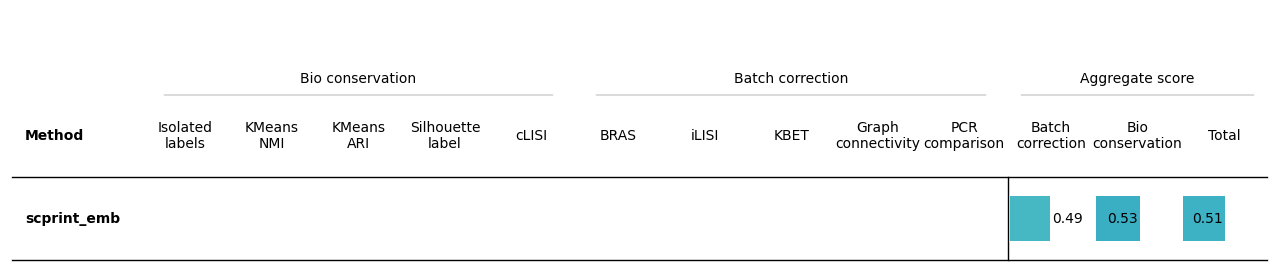

              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
scprint_emb          0.509863          0.426683          0.134236   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
scprint_emb          0.558273               1.0          0.778155   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
scprint_emb               0.0          0.849659           0.825514   
Metric Type  Batch correction  Batch correction   Batch correction   

               PCR comparison Batch correction Bio conservation  \
Embedding                                                         
scprint_emb                 0  

/lustre/fswork/projects/rech/xeg/uat95fg/scdataloader/scdataloader/utils.py:427: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


predict epoch start


  0%|          | 0/4716 [00:00<?, ?it/s]

/linkhome/rech/gennth01/uat95fg/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


...

Metrics:  80%|████████  | 8/10 [1:13:20<07:15, 217.53s/it, Batch correction: graph_connectivity]

Metrics:  80%|████████  | 8/10 [1:13:20<07:15, 217.53s/it, Batch correction: pcr_comparison]    

Metrics:  90%|█████████ | 9/10 [1:13:23<02:30, 150.33s/it, Batch correction: pcr_comparison]

Embeddings: 100%|██████████| 1/1 [1:13:23<00:00, 4403.21s/it]

Embeddings: 100%|██████████| 1/1 [1:13:23<00:00, 4403.21s/it]

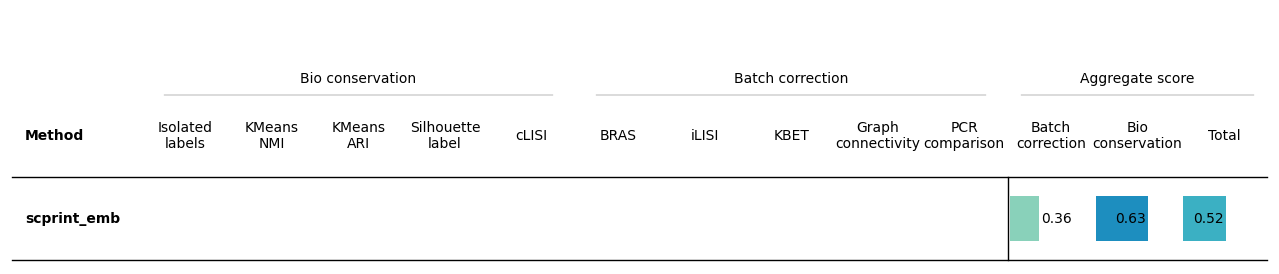

              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
scprint_emb          0.657649          0.567372          0.391042   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
scprint_emb           0.54277          0.999368          0.682742   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
scprint_emb           0.03697          0.193596           0.872287   
Metric Type  Batch correction  Batch correction   Batch correction   

               PCR comparison Batch correction Bio conservation  \
Embedding                                                         
scprint_emb                 0  

/lustre/fswork/projects/rech/xeg/uat95fg/scdataloader/scdataloader/utils.py:427: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


predict epoch start


  0%|          | 0/5153 [00:00<?, ?it/s]

/linkhome/rech/gennth01/uat95fg/.local/share/uv/python/cpython-3.12.11-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


...

Metrics:  80%|████████  | 8/10 [1:28:10<08:22, 251.23s/it, Batch correction: graph_connectivity]

Metrics:  80%|████████  | 8/10 [1:28:10<08:22, 251.23s/it, Batch correction: pcr_comparison]    

Metrics:  90%|█████████ | 9/10 [1:28:12<02:53, 173.44s/it, Batch correction: pcr_comparison]

Embeddings: 100%|██████████| 1/1 [1:28:12<00:00, 5292.44s/it]

Embeddings: 100%|██████████| 1/1 [1:28:12<00:00, 5292.44s/it]

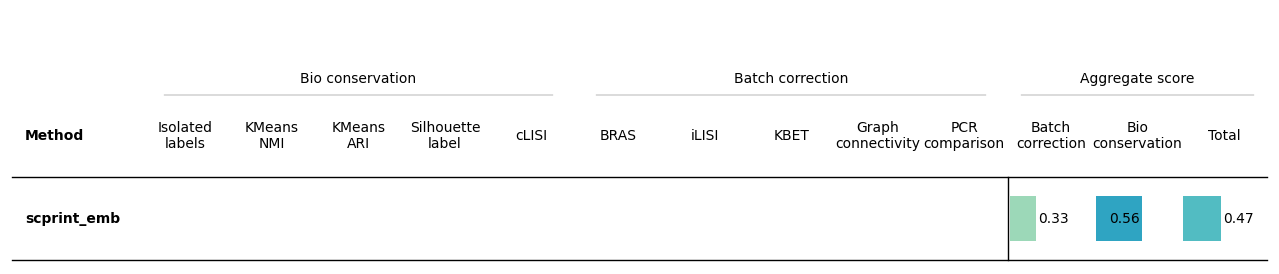

              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
scprint_emb           0.51565          0.524355           0.26164   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
scprint_emb          0.517916          0.985155          0.636071   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI              KBET Graph connectivity  \
Embedding                                                            
scprint_emb          0.006423          0.144493           0.842398   
Metric Type  Batch correction  Batch correction   Batch correction   

               PCR comparison Batch correction Bio conservation  \
Embedding                                                         
scprint_emb                 0  

In [14]:
for name, url in list(datasets.items())[2:]:
    print("doing ", name)
    if not os.path.exists(LOC + "temp/" + name + "_proc.h5ad"):
        adata = sc.read(LOC + name + ".h5ad", backup_url=url)
        preprocessor = Preprocessor(
            force_preprocess=True,
            skip_validate=True,
            # drop_non_primary=False,
            is_symbol=False,
            do_postp=metacell,
        )
        adata = preprocessor(adata)
        if metacell:
            sc.pp.neighbors(adata, use_rep="X_pca")
        adata.write_h5ad(LOC + "temp/" + name + "_proc.h5ad")
    else:
        adata = sc.read(LOC + "temp/" + name + "_proc.h5ad")

    embed = Embedder(
        how="random expr",
        max_len=2300,
        num_workers=8,
        pred_embedding=["cell_type_ontology_term_id"],
        doplot=False,
    )
    n_adata, _ = embed(model, adata)
    metrics[name + "_ref_cls"] = compute_classification(
        n_adata,
        ["cell_type_ontology_term_id"],
        label_decoders=model.label_decoders,
        labels_hierarchy=model.labels_hierarchy,
    )
    n_adata_last = n_adata[
        n_adata.obs["donor_id"] == n_adata.obs["donor_id"].unique()[-1]
    ]
    metrics[name + "_cls"] = compute_classification(
        n_adata_last,
        ["cell_type_ontology_term_id"],
        label_decoders=model.label_decoders,
        labels_hierarchy=model.labels_hierarchy,
    )
    print(metrics)
    n_adata.obs = n_adata.obs.iloc[:, :100]
    n_adata.obsm["scprint_emb"] = sc.pp.pca(n_adata.obsm["scprint_emb"], chunked=True)
    bm = Benchmarker(
        n_adata,
        batch_key="donor_id",  # "batch",  # batch, tech, assay_ontology_term_id, donor_id
        label_key="cell_type",  # celltype
        embedding_obsm_keys=["scprint_emb"],
        bio_conservation_metrics=BioConservation(),
        batch_correction_metrics=BatchCorrection(),
        n_jobs=10,
    )
    del n_adata, adata
    bm.benchmark()
    metrics[name + "_batch_corr"] = bm.get_results()
    bm.plot_results_table(min_max_scale=False)
    print(metrics[name + "_batch_corr"])

In [15]:
metrics

{'cellxgene_census/hypomap_ref_cls': {'cell_type_ontology_term_id': {'accuracy': 0.8985464700915763,
   'macro': 0.5388320534886858,
   'micro': 0.8985464700915763,
   'weighted': 0.8781595385460352}},
 'cellxgene_census/hypomap_cls': {'cell_type_ontology_term_id': {'accuracy': 0.9430379746835443,
   'macro': 0.6611934880344028,
   'micro': 0.9430379746835443,
   'weighted': 0.9368647424293999}},
 'cellxgene_census/hypomap_batch_corr':               Isolated labels        KMeans NMI        KMeans ARI  \
 Embedding                                                           
 scprint_emb          0.509863          0.426683          0.134236   
 Metric Type  Bio conservation  Bio conservation  Bio conservation   
 
              Silhouette label             cLISI              BRAS  \
 Embedding                                                           
 scprint_emb          0.558273               1.0          0.778155   
 Metric Type  Bio conservation  Bio conservation  Batch correction   

# same with scPRINT-V1


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [16]:
emb = pd.DataFrame(
    data={
        "Isolated labels": [
            0.566661,
            0.511032,
        ],
        "KMeans NMI": [
            0.645338,
            0.238028,
        ],
        "KMeans ARI": [
            0.31973,
            0.11652,
        ],
        "Silhouette label": [
            0.508098,
            0.514257,
        ],
        "cLISI": [
            0.997801,
            0.956136,
        ],
        "BRAS": [
            0.816372,
            0.74002,
        ],
        "iLISI": [
            0.052263,
            0.150554,
        ],
        "KBET": [
            0.314974,
            0.169856,
        ],
        "Graph connectivity": [
            0.764403,
            0.768737,
        ],
        "PCR comparison": [
            0,
            0.269315,
        ],
        "Batch correction": [
            0.389602,
            0.419696,
        ],
        "Bio conservation": [
            0.607526,
            0.467195,
        ],
        "Total": [
            0.520356,
            0.448195,
        ],
    },
    index=["mouse_pancreas_atlas", "hypomap", "gtex_v9", "dkd"],
)

ValueError: Length of values (2) does not match length of index (4)

In [ ]:
{
    "dkd_ref_cls": {
        "accuracy": 0.49290381866448846,
        "macro": 0.38033720115060904,
        "micro": 0.49290381866448846,
        "weighted": 0.4396242689149366,
    },
    "dkd_cls": {
        "accuracy": 0.5134390075809786,
        "macro": 0.27219339805559467,
        "micro": 0.5134390075809786,
        "weighted": 0.46872000310836415,
    },
    "gtex_v9_ref_cls": {
        "accuracy": 0.6626244465059342,
        "macro": 0.45003794206824765,
        "micro": 0.6626244465059342,
        "weighted": 0.6077866721175682,
    },
    "gtex_v9_cls": {
        "accuracy": 0.3282208588957055,
        "macro": 0.44908793724253965,
        "micro": 0.3282208588957055,
        "weighted": 0.20892503251540293,
    },
    "hypomap_ref_cls": {
        "accuracy": 0.898346431122946,
        "macro": 0.5400846013058894,
        "micro": 0.898346431122946,
        "weighted": 0.877997460703883,
    },
    "hypomap_cls": {
        "accuracy": 0.930379746835443,
        "macro": 0.6235067220911508,
        "micro": 0.930379746835443,
        "weighted": 0.9189875550891025,
    },
}

In [ ]:
for k, v in metrics.items():
    print(f"{k}: {v['accuracy']}")

In [ ]:
for k, v in res_label.items():
    if k is None:
        continue
    print(f"{k.split('/')[1]}: ")
    for l, w in v.items():
        if w is None:
            continue
        print(f"    {l}: {w['accuracy']}")
    m = 0
    for l, w in metrics.items():
        if l.startswith(k.split("/")[1]):
            if w["accuracy"] > m:
                m = w["accuracy"]
    print(f"    scPRINT-2 (zero-shot): {m:.3f}")

In [ ]:
import pandas as pd

In [ ]:
FACT = 1.5
emb.iloc[:, -1] * (1 + FACT) - (emb.iloc[:, -2] * FACT + emb.iloc[:, -3])

In [ ]:
for k, v in res.items():
    if k is None:
        continue
    print(f"{k.split('/')[1]}: ")
    for l, w in v.items():
        cell = 0

        for c in [
            "ari",
            "nmi",
            "isolated_label_asw",
            "clisi",
            "asw_label",
        ]:
            if w[c] == "NA":
                continue
            cell += w[c]
        cell /= 5
        batch = 0

        for b in [
            "pcr",
            "graph_connectivity",
            "asw_batch",
            "ilisi",
            "kbet",
        ]:
            if w[b] == "NA":
                continue
            batch += w[b]
        batch /= 5
        total = cell * 0.4 + batch * 0.6
        print(f"    {l}: {total:.3f}")
    # print(f"         Bio: {cell:.3f}")
    # print(f"         Batch: {batch:.3f}")
    if k.split("/")[1] not in emb.index:
        continue
    print(f"   scPRINT-2 (zero-shot): {emb.loc[k.split('/')[1], 'Total']:.3f}")
    # print(f"         Bio: {emb.loc[k.split('/')[1], 'Bio conservation']:.3f}")
# print(f"         Batch: {emb.loc[k.split('/')[1], 'Batch correction']:.3f}")

# cell_cycle_conservation
# hvg_overlap
# isolated_label_asw

# same with finetuning batch


In [ ]:
## ISSUE: many batches to correct, mmd might not be the right tool

## same with fine tuning class


In [ ]:
finetuner = FinetuneBatchClass(
    batch_key="donor_id",
    max_len=3000,
)

model, metrics[name + "_fine_tuning"] = finetuner(model=model, train_adata=adata)

In [ ]:
metrics